## Step 1: Data Preparation & EDA
โหลด ทำความสะอาด และสำรวจข้อมูลเบื้องต้น เพื่อทำความเข้าใจโครงสร้างก่อนวิเคราะห์

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ดึงข้อมูลไฟล์ และใช้ภาษาไทยใน matplot
plt.rcParams["font.family"] = "Tahoma"
df = pd.read_csv("avg_income.csv")


#Data Cleaning
print("--- Data Cleaning Log ---")
print(f"1. Initial rows: {df.shape[0]} rows, {df.shape[1]} columns")


null_summary = df.isnull().sum()
print("2. Columns with Null values:" , null_summary[null_summary > 0].to_string())

# ลบแถวซ้ำ
dup_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"3. Duplicates removed: {dup_count} rows")

# แปลง value เป็นตัวเลข
df["value"] = pd.to_numeric(df["value"], errors="coerce").fillna(0)

# Clean \n และช่องว่างซ่อนเร้น
df["source_income3"] = df["source_income3"].astype(str).str.replace("\n", "", regex=False).str.strip()

print(f"4. Rows after cleaning: {df.shape[0]} rows")

# กรอง df_total เฉพาะ รายได้ทั้งสิ้นต่อเดือน
df_total = df[df["source_income1"] == "รายได้ทั้งสิ้นต่อเดือน"].copy()



# STEP 2: EDA เบื้องต้น
print("\n--- Basic EDA ---")
national_avg = df_total["value"].mean()

#เก็บค่าตัวแปร
max_val     = df_total["value"].max()
min_val     = df_total[df_total["value"] > 0]["value"].min()
n_province  = df_total["province"].nunique()
n_occ       = df_total["soc_eco_class2"].nunique()

print(f"Average household income  : {national_avg:,.2f} THB/month")
print(f"Maximum income             : {max_val:,.2f} THB/month")
print(f"Minimum income (>0)        : {min_val:,.2f} THB/month")
print(f"Number of provinces        : {n_province}")
print(f"Occupation groups (class2) : {n_occ}")
print("\nOccupation group breakdown (soc_eco_class1):")
print(df_total["soc_eco_class1"].value_counts().to_string())
print("\nBasic statistics — value column:")
print(df_total["value"].describe().apply(lambda x: f"{x:,.2f}").to_string())

--- Data Cleaning Log ---
1. Initial rows: 7700 rows, 11 columns
2. Columns with Null values: attribute    6865
3. Duplicates removed: 0 rows
4. Rows after cleaning: 7700 rows

--- Basic EDA ---
Average household income  : 25,327.28 THB/month
Maximum income             : 181,322.00 THB/month
Minimum income (>0)        : 4,452.00 THB/month
Number of provinces        : 77
Occupation groups (class2) : 10

Occupation group breakdown (soc_eco_class1):
soc_eco_class1
ลูกจ้าง                                     385
ผู้ถือครองทำการเกษตร/เพาะเลี้ยง             231
ผู้ประกอบธุรกิจของตนเองที่ไม่ใช่การเกษตร     77
ผู้ไม่ได้ปฏิบัติงานเชิงเศรษฐกิจ              77

Basic statistics — value column:
count        770.00
mean      25,327.28
std       14,594.87
min         -600.00
25%       16,442.25
50%       22,363.50
75%       30,015.25
max      181,322.00


## ข้อ 1: ใครได้รับค่าตอบแทนแค่ไหน?

**กราฟเลือก**: Horizontal Bar Chart จัดเรียงจากมากไปน้อย  
**เหตุผล**: เหมาะสำหรับเปรียบเทียบหลายกลุ่มพร้อมกัน ชื่อกลุ่มอาชีพยาว แนวนอนอ่านง่ายกว่า และเห็นช่องว่างรายได้ระหว่างกลุ่มได้ชัดเจน

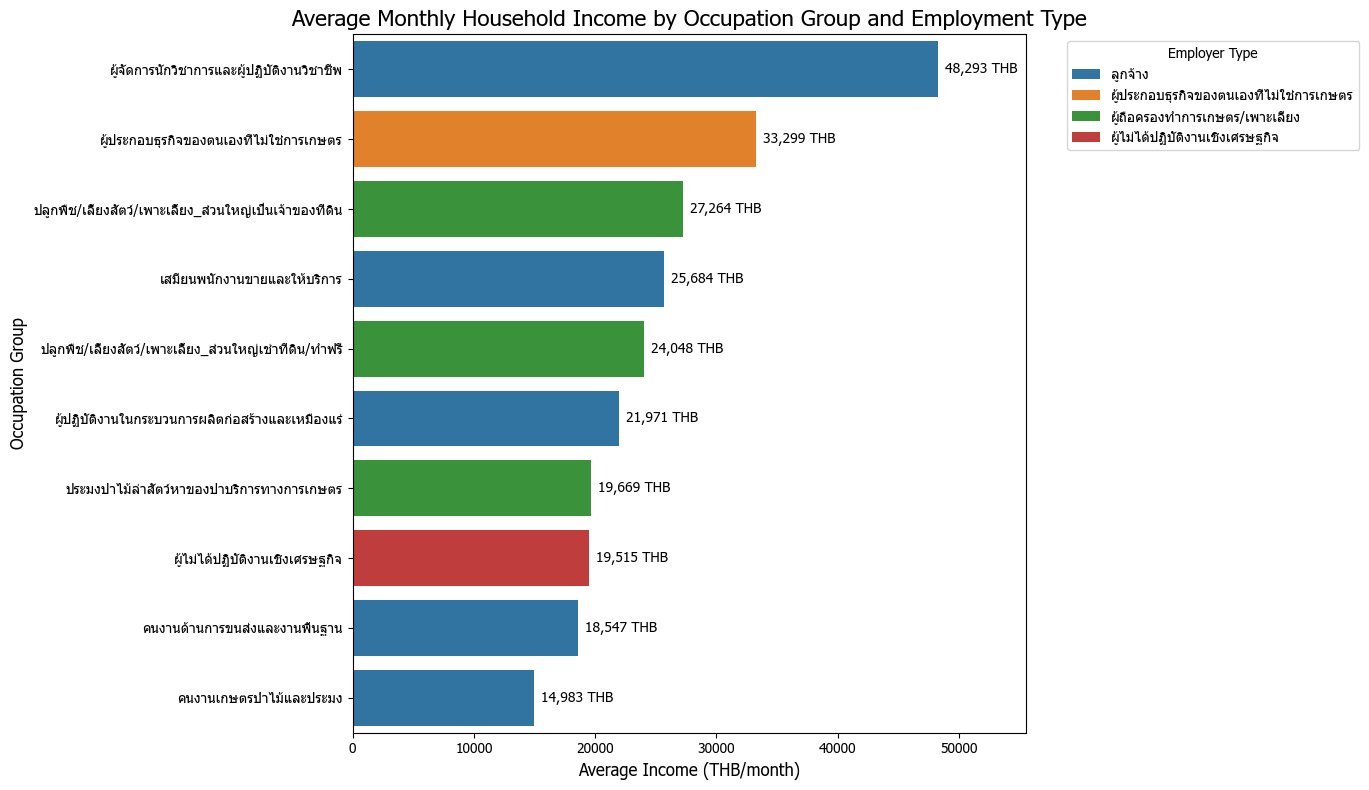

In [2]:
# กรองเฉพาะ "รายได้ทั้งสิ้นต่อเดือน" เพื่อดูรายได้รวม
df_q1 = df_total.groupby(["soc_eco_class1", "soc_eco_class2"])["value"].mean().reset_index()
df_q1 = df_q1.sort_values(by="value", ascending=False)

plt.figure(figsize=(14, 8))
ax = sns.barplot(data=df_q1, x="value", y="soc_eco_class2", hue="soc_eco_class1", dodge=False)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f} THB", padding=5, fontsize=10)
plt.xlim(0, df_q1["value"].max() * 1.15)

plt.title("Average Monthly Household Income by Occupation Group and Employment Type", fontsize=16)
plt.xlabel("Average Income (THB/month)", fontsize=12)
plt.ylabel("Occupation Group", fontsize=12)
plt.legend(title="Employer Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insight ข้อ 1

**What (เห็นอะไร)**  
ผู้จัดการ/นักวิชาการ/ผู้ปฏิบัติงานวิชาชีพ มีรายได้เฉลี่ยสูงสุด ขณะที่คนงานเกษตร/ป่าไม้/ประมง มีรายได้ต่ำสุด  
ช่องว่างระหว่างกลุ่มสูงสุดและต่ำสุดอยู่ที่ประมาณ **3 เท่า**

**Why (เพราะอะไร)**  
กลุ่มที่ใช้ทักษะสูงและอยู่ในระบบเศรษฐกิจทางการ (ลูกจ้างองค์กร) ได้รับผลตอบแทนสูงกว่ากลุ่มที่พึ่งพาแรงงานกายและเกษตรกรรม ซึ่งมีความเสี่ยงสูงกว่าและไม่มีสวัสดิการคุ้มครอง

**So What (ควรทำอะไร)**  
นโยบายพัฒนาทักษะแรงงาน (Upskilling) และการยกระดับค่าแรงขั้นต่ำสำหรับกลุ่มเกษตรกรและแรงงานพื้นฐาน จะช่วยลดช่องว่างรายได้ได้ตรงจุดที่สุด


## ข้อ 2: ความเหลื่อมล้ำอยู่ที่ไหน?

**กราฟเลือก**: Dumbbell Chart (จุดเชื่อมเส้น)  
**เหตุผล**: แสดง Min และ Max ของรายได้ภายในจังหวัดพร้อมกันในแถวเดียว ทำให้เห็นช่องว่างความเหลื่อมล้ำภายในจังหวัดได้ชัดเจนกว่า Bar Chart ธรรมดา

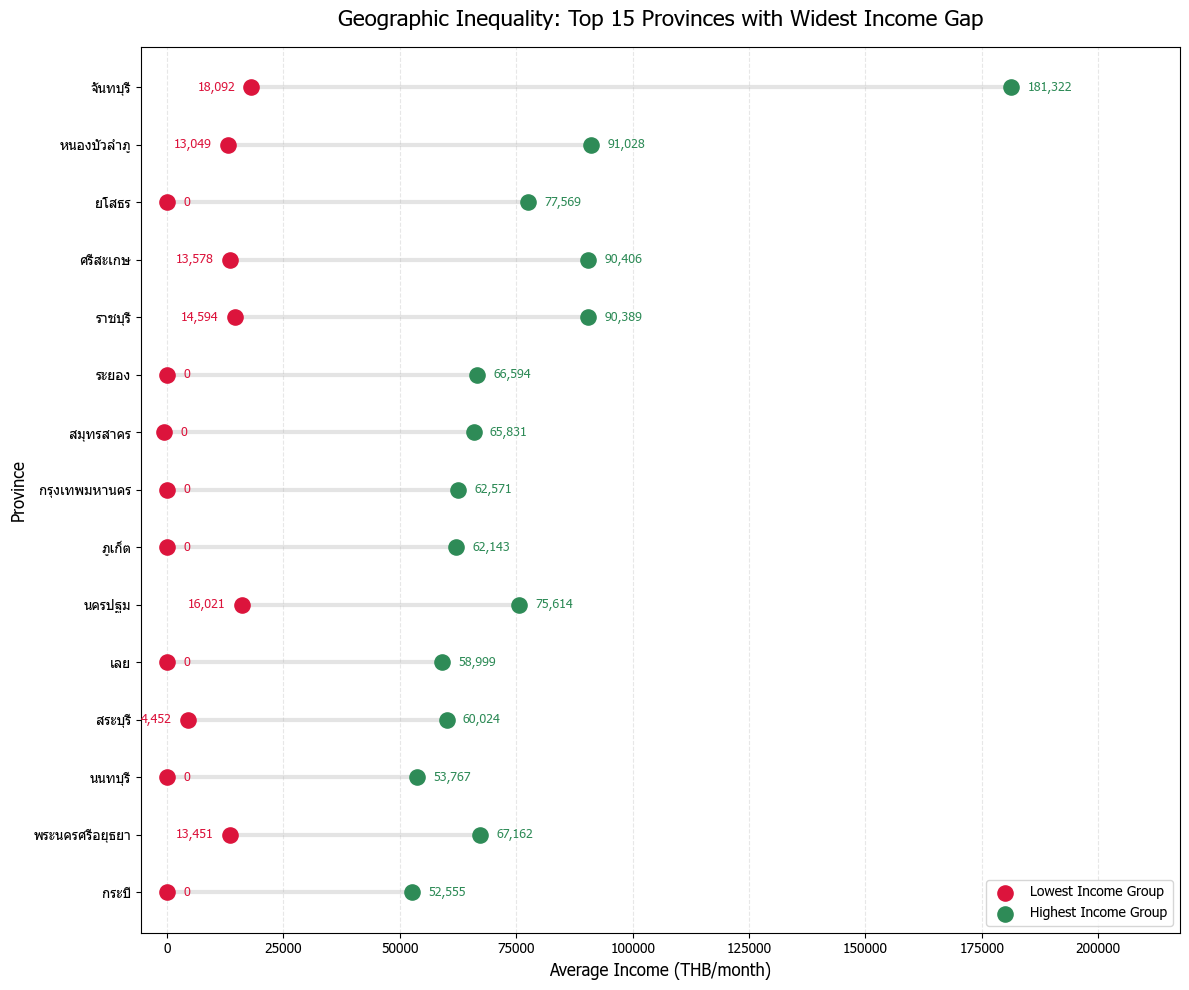

In [3]:
# หาค่า Max/Min/Avg ในแต่ละจังหวัด
df_q2 = df_total.groupby("province")["value"].agg(Max_Income="max", Min_Income="min", Avg_Income="mean").reset_index()
df_q2["Income_Gap"] = df_q2["Max_Income"] - df_q2["Min_Income"]

# top 15 จังหวัดที่เหลื่อมล้ำสูงสุด
df_q2_top = df_q2.sort_values(by="Income_Gap", ascending=True).tail(15)

plt.figure(figsize=(12, 10))
plt.hlines(y=df_q2_top["province"], xmin=df_q2_top["Min_Income"], xmax=df_q2_top["Max_Income"],
           color="lightgrey", alpha=0.6, linewidth=3, zorder=1)
plt.scatter(df_q2_top["Min_Income"], df_q2_top["province"], color="crimson", s=120, label="Lowest Income Group", zorder=3)
plt.scatter(df_q2_top["Max_Income"], df_q2_top["province"], color="seagreen", s=120, label="Highest Income Group", zorder=3)

offset = 3500
for _, row in df_q2_top.iterrows():
    if row["Min_Income"] <= 0:
        plt.text(row["Min_Income"] + offset, row["province"], "0",
                 ha="left", va="center", fontsize=9, color="crimson")
    else:
        plt.text(row["Min_Income"] - offset, row["province"], f"{row["Min_Income"]:,.0f}",
                 ha="right", va="center", fontsize=9, color="crimson")
    plt.text(row["Max_Income"] + offset, row["province"], f"{row["Max_Income"]:,.0f}",
             ha="left", va="center", fontsize=9, color="seagreen")

plt.xlim(df_q2_top["Min_Income"].min() - 5000, df_q2_top["Max_Income"].max() * 1.2)
plt.title("Geographic Inequality: Top 15 Provinces with Widest Income Gap", fontsize=16, pad=15)
plt.xlabel("Average Income (THB/month)", fontsize=12)
plt.ylabel("Province", fontsize=12)
plt.legend(loc="lower right")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Insight ข้อ 2

**What (เห็นอะไร)**  
จันทบุรีมีช่องว่างรายได้กว้างที่สุด (Max สูงมากแต่ Min ต่ำ) หลายจังหวัดภาคอีสาน เช่น ยโสธร ศรีสะเกษ มีทั้งรายได้ต่ำ และช่องว่างกว้าง  
บางจังหวัดมี Min = 0 หมายถึงมีกลุ่มที่ไม่มีรายได้จากแหล่งนั้นเลย

**Why (เพราะอะไร)**  
จังหวัดที่มีช่องว่างสูงมักมีโครงสร้างเศรษฐกิจแบบ Dual Economy คือมีทั้งกลุ่มธุรกิจขนาดใหญ่ (รายได้สูง) และเกษตรกร/แรงงานรายวัน (รายได้ต่ำ) อยู่ร่วมกัน

**So What (ควรทำอะไร)**  
จังหวัดที่มีค่าเฉลี่ยต่ำ + ช่องว่างสูง เช่น ยโสธร ควรได้รับงบประมาณพัฒนายกระดับรายได้โดยรวม ส่วนจังหวัดที่มีค่าเฉลี่ยสูงแต่ช่องว่างกว้าง ควรเน้นนโยบายลดความเหลื่อมล้ำภายในจังหวัด


## ข้อ 3: รายได้มาจากไหน และใครพึ่งพาอะไร?

**กราฟเลือก**: Pie Chart แบบ Grid (5x2) แยกตามกลุ่มอาชีพ  
**เหตุผล**: แสดงสัดส่วนแหล่งรายได้ของแต่ละกลุ่มอาชีพ ทำให้เห็น โครงสร้างรายได้ และความเสี่ยงของแต่ละกลุ่มได้ทันที เช่น กลุ่มที่พึ่งพารายได้ประเภทเดียวสูงกว่า 70% มีความเปราะบางมากกว่า

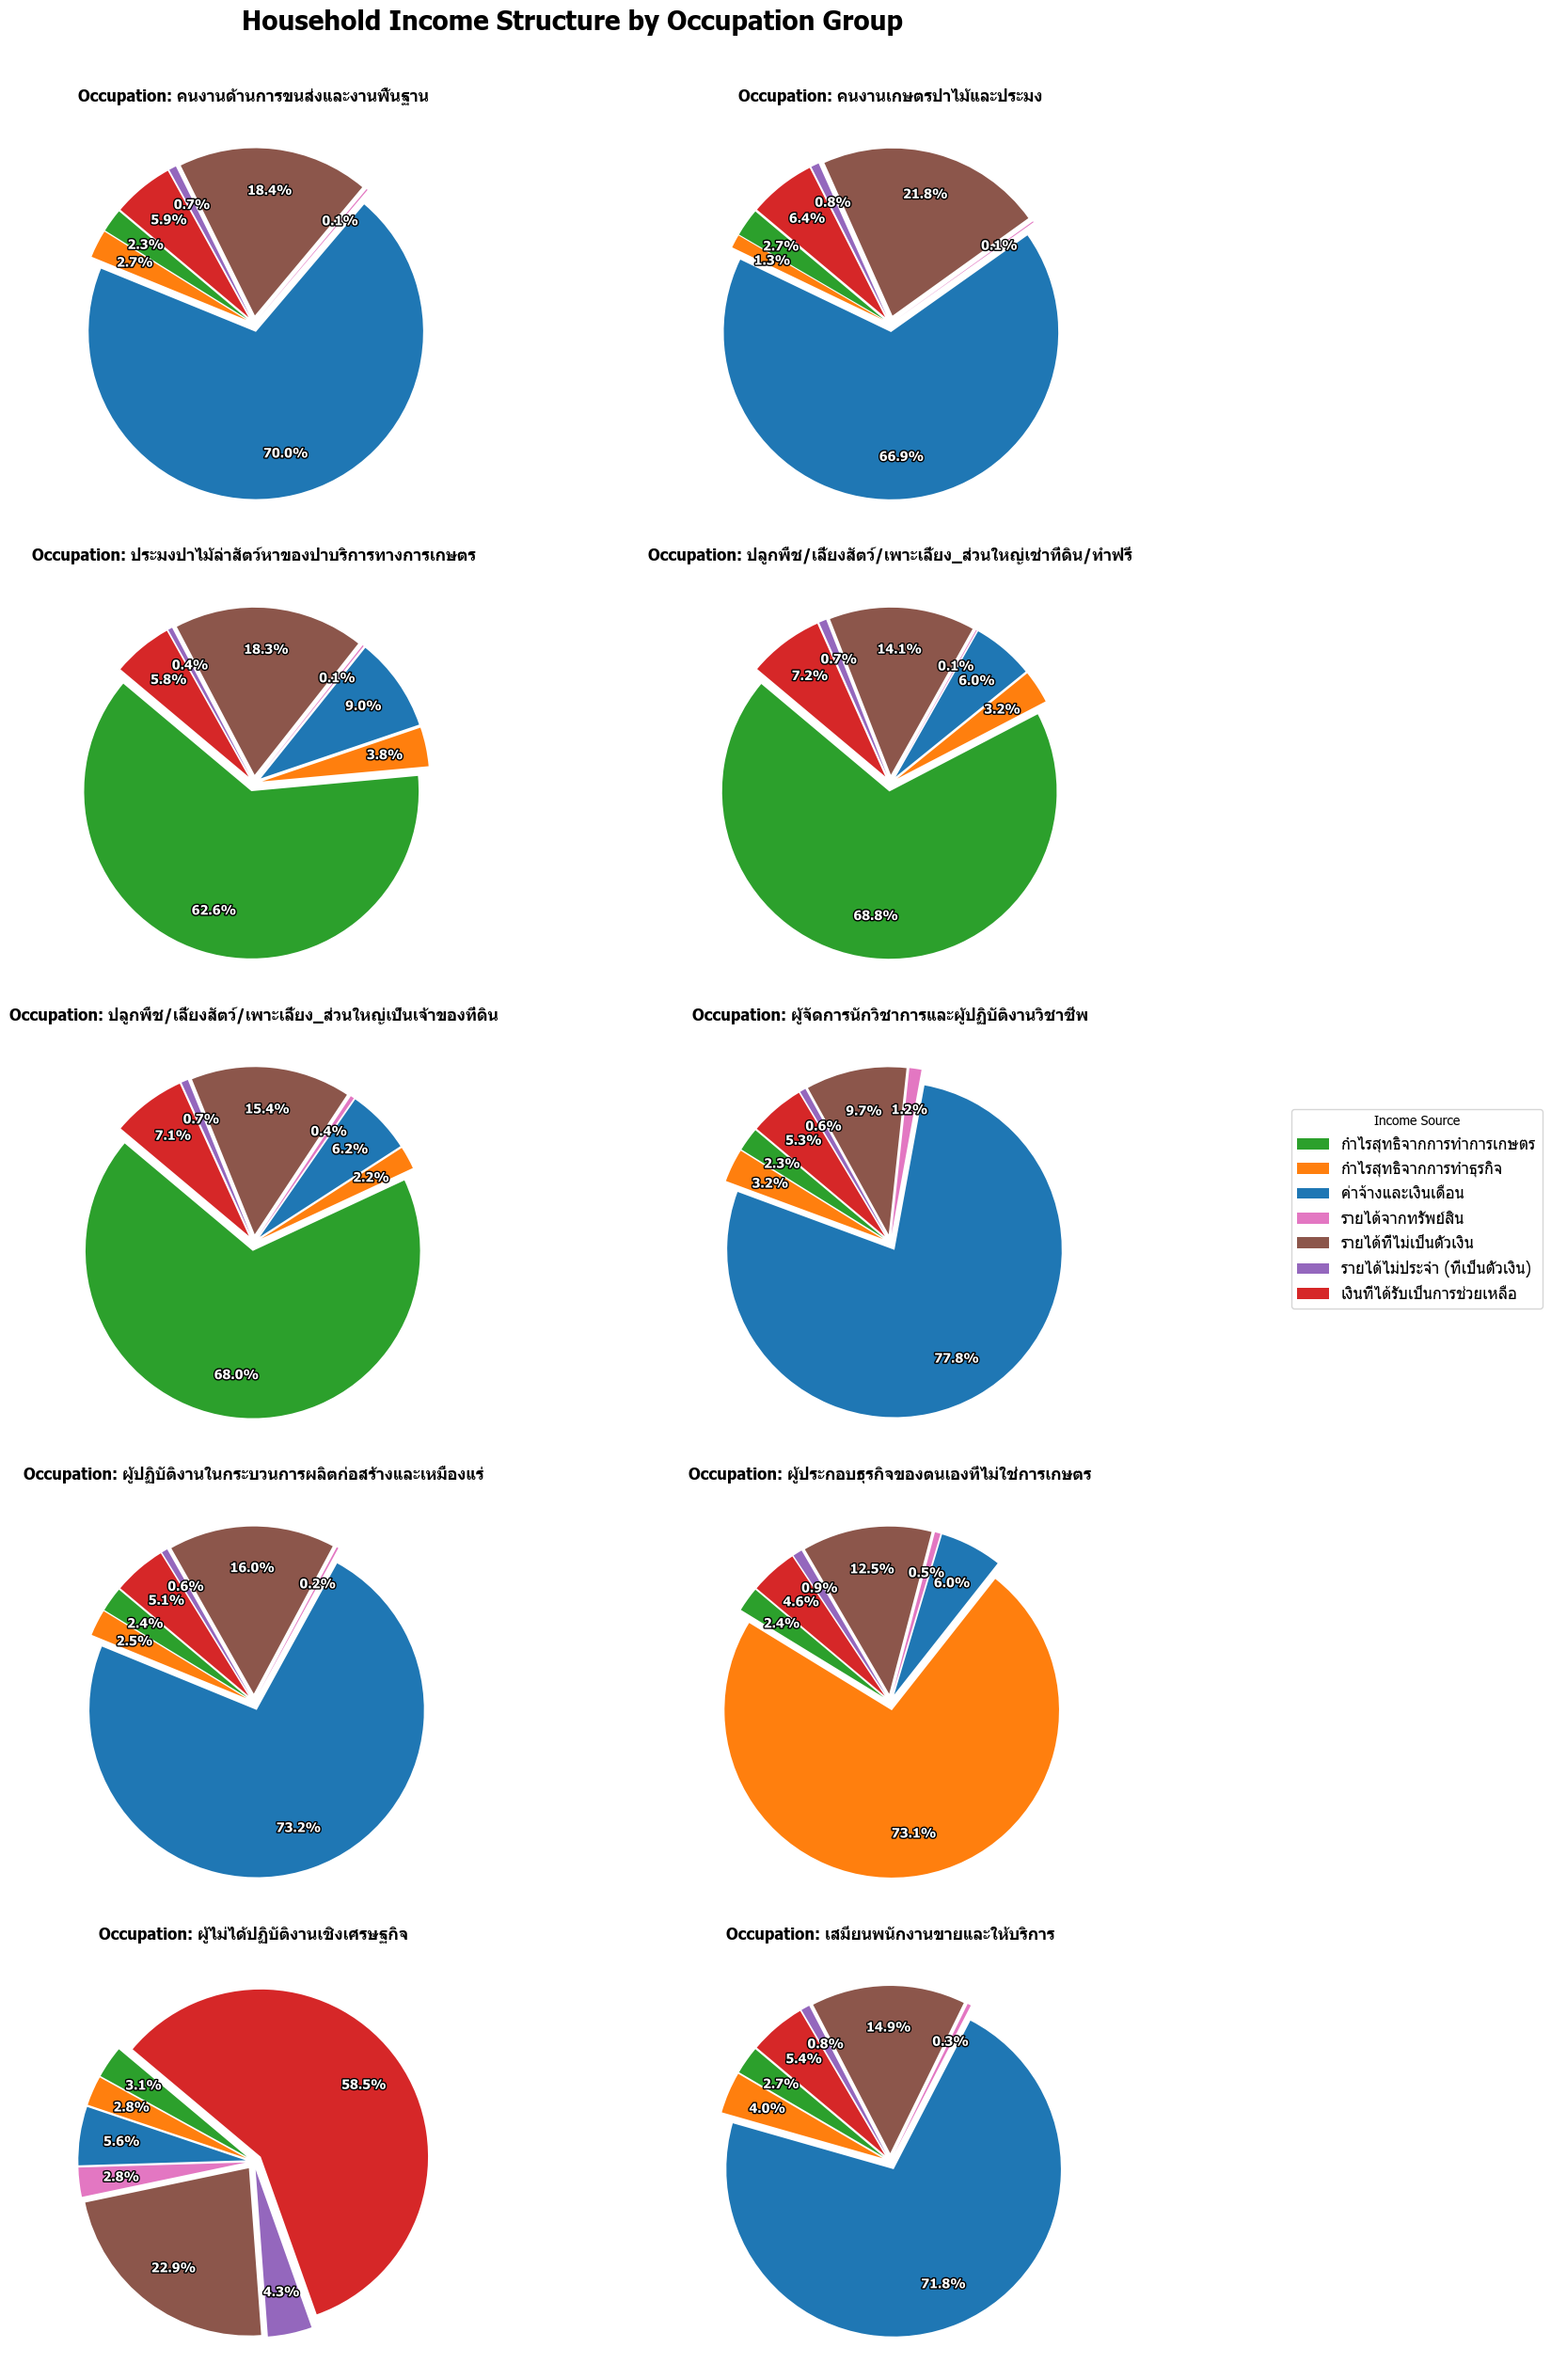

In [4]:
from matplotlib import patheffects as path_effects

# กำหนดรหัสสี
my_colors = [
    "#2ca02c", # กำไรสุทธิจากการทำการเกษตร
    "#ff7f0e", # กำไรสุทธิจากการทำธุรกิจ
    "#1f77b4", # ค่าจ้างและเงินเดือน
    "#e377c2", # รายได้จากทรัพย์สิน
    "#8c564b", # รายได้ที่ไม่เป็นตัวเงิน
    "#9467bd", # รายได้ไม่ประจำ (ที่เป็นตัวเงิน)
    "#d62728"  # เงินที่ได้รับเป็นการช่วยเหลือ
]

sources = [
    "กำไรสุทธิจากการทำการเกษตร",
    "กำไรสุทธิจากการทำธุรกิจ",
    "ค่าจ้างและเงินเดือน",
    "รายได้จากทรัพย์สิน",
    "รายได้ที่ไม่เป็นตัวเงิน",
    "รายได้ไม่ประจำ (ที่เป็นตัวเงิน)",
    "เงินที่ได้รับเป็นการช่วยเหลือ"
]
color_map = dict(zip(sources, my_colors))

# ใช้ df ที่ clean แล้วจาก Cell 1 (ไม่โหลดซ้ำ)
df_q3 = df[df["source_income3"].isin(sources)]
occ_income = df_q3.groupby(["soc_eco_class2", "source_income3"])["value"].mean().unstack(fill_value=0)

occupations = occ_income.index
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 25))
axes = axes.flatten()

for i, occ in enumerate(occupations):
    data = occ_income.loc[occ]
    data = data[data > 0]
    current_colors = [color_map[s] for s in data.index]
    wedges, texts, autotexts = axes[i].pie(
        data, autopct="%1.1f%%", startangle=140,
        colors=current_colors, pctdistance=0.75,
        explode=[0.05] * len(data)
    )
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_weight("bold")
        autotext.set_fontsize(10)
        autotext.set_path_effects([path_effects.withStroke(linewidth=2, foreground="black")])
    axes[i].set_title(f"Occupation: {occ}", fontsize=12, fontweight="bold", pad=10)

fig.legend(sources, title="Income Source", loc="center right", bbox_to_anchor=(1.15, 0.5), fontsize=12)
plt.suptitle("Household Income Structure by Occupation Group", fontsize=20, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


### Insight ข้อ 3

**What (เห็นอะไร)**  
- **ผู้จัดการ/นักวิชาชีพ**: พึ่งพาค่าจ้าง/เงินเดือนสูงมาก (>75%) — กระจุกตัวในรายได้ประจำ  
- **ผู้ประกอบธุรกิจตนเอง**: กำไรธุรกิจเป็นแหล่งรายได้หลัก (>70%)  
- **เกษตรกร**: กำไรเกษตรคือแหล่งรายได้หลัก (>60%)  
- **ผู้ไม่ได้ปฏิบัติงาน**: พึ่งพาเงินช่วยเหลือมากที่สุดเมื่อเทียบกับกลุ่มอื่น

**Why (เพราะอะไร)**  
กลุ่มที่รายได้กระจุกอยู่แหล่งเดียวสูง (>70%) มีความเสี่ยงและเปราะบางทางเศรษฐกิจมากกว่า เพราะถ้าแหล่งรายได้หลักหยุดชะงัก เช่น ภัยแล้ง ตกงาน ธุรกิจล้ม จะกระทบรุนแรงกว่ากลุ่มที่มีรายได้หลากหลาย

**So What (ควรทำอะไร)**  
- กลุ่มเกษตรกร: ควรส่งเสริมให้มีรายได้เสริมนอกฤดูกาลเก็บเกี่ยว เพื่อลดความเสี่ยงจากราคาพืชผลผันผวน  
- กลุ่มผู้ประกอบธุรกิจ SME: ควรมีระบบประกันสังคมหรือกองทุนสำรองสำหรับ Self-employed  
- กลุ่มผู้ไม่ได้ปฏิบัติงาน: นโยบายสวัสดิการรัฐควรมีความต่อเนื่องและคาดเดาได้
